In [1]:

#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("PIXE_Bremsstrahlung.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from PIXE_functions import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.2f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PIXE_Bremsstrahlung.ipynb started: Wed, 08 Apr 2026 13:26:23
INFO: SETUP COMPLETE (1937.50 ms)
---------------------------------------


In [74]:
def intensity(alpha:float, current:float, live_time:float, Z_target:int, el_energy:float, brems_energy:float):
    return 10

def g_func(Z_target:int, el_energy:float, brems_energy:list):
    '''
    A numerical function describing a bremsstrahlung background.\n
    Taken from Castellano et al. 2004 (Bremsstrahlung1)
    '''
    # factor1 = np.sqrt(Z_target)*(el_energy - brems_energy)/(brems_energy)
    # factor2 = (-54.86 - 1.072*brems_energy + 0.2835*el_energy + 30.4*np.log(Z_target)+(875)/(Z_target**2 * el_energy**(0.08)))
    factor1 = np.sqrt(Z_target)*(el_energy - brems_energy)/(brems_energy)
    sumfactor = (-73.90 - 1.2446*brems_energy + 36.502*np.log(Z_target) + (148.5*el_energy**(0.1293))/(Z_target))
    factor2 = (1 + (-0.006624 + 0.0002906*el_energy)*((Z_target)/(brems_energy)))
    
    return factor1*sumfactor*factor2
    

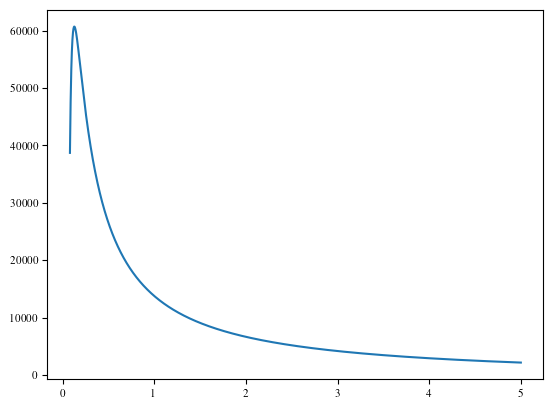

In [75]:
B_energy = np.linspace(0.08,5,4000)
plt.plot(B_energy, g_func(Z_target=79, el_energy=20, brems_energy=B_energy))
plt.show()